# Run in Google Colab

In [1]:
localdisk = '/content/drive/MyDrive/workdir/wfci/analysis'
minrank = 1; maxrank = 3; # rank = how many components per brain region. Set maxrank to around 10 for regular dataset.
rank_range = (minrank, maxrank, 1)
min_pixels = 100 # minimum number of pixels in Allen map for it to be considered a brain region
loc_thresh = 80 # Localization threshold, i.e. percentage of area restricted to be inside the 'Allen boundary'
r2_thresh = 0.99 # Fraction of variance in the data to capture with LocaNMF
nonnegative_temporal = False # Do you want nonnegative temporal components? The data itself should also be nonnegative in this case.

In [ ]:
## Runtime should be GPU
from google.colab import drive
drive.mount('/content/drive')

import os
from os.path import join as pjoin
os.chdir('/content/drive/MyDrive/workdir/wfci/locaNMF_repo')

# locanmf/video.py, class RegionMetadata(FactorCollection) is modified as below
# self.support = TensorFactor((max_num_components, region_shape[0]),
#                                    device=device,
#                                    dtype=torch.uint8)

# self.support = TensorFactor((max_num_components, region_shape[0]),
#                                    device=device,
#                                    dtype=torch.bool)

# wfield/utils.py, reconstruct is modified as below
# u@svt -> np.matmul(u, svt)


import sys
sys.path.append('/content/drive/MyDrive/workdir/wfci/locaNMF_repo')
sys.path.append('/content/drive/MyDrive/workdir/wfci/')

## check if package locanmf is successfully installed.
# from locanmf import LocaNMF
!pip install ipympl
!pip install wfield
from locanmf import *
from postprocess_mod import *

import sys
from os.path import join as pjoin
from tqdm import tqdm
import numpy as np
import scipy.io as sio
from sklearn.cross_decomposition import CCA
import matplotlib.pyplot as plt
import torch
import time
import warnings
warnings.filterwarnings("ignore")
from locanmf import LocaNMF
%matplotlib widget
%matplotlib inline
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
LocaNMF.version()

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 28.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.0/961.0 kB 59.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 31.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 75.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 83.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# User-defined Parameters
- Specify that the calculation is run on CUDA-supported GPU
- Set the hyperparameters of locaNMF algo

In [3]:
## [OPTIONAL] if cuda support, uncomment following lines
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"
device='cuda'

# minrank = 1; maxrank = 10; # rank = how many components per brain region. Set maxrank to around 10 for regular dataset.
# rank_range = (minrank, maxrank, 1)
# min_pixels = 100 # minimum number of pixels in Allen map for it to be considered a brain region
# loc_thresh = 80 # Localization threshold, i.e. percentage of area restricted to be inside the 'Allen boundary'
# r2_thresh = 0.99 # Fraction of variance in the data to capture with LocaNMF
# nonnegative_temporal = False # Do you want nonnegative temporal components? The data itself should also be nonnegative in this case.

# Load & Format Data

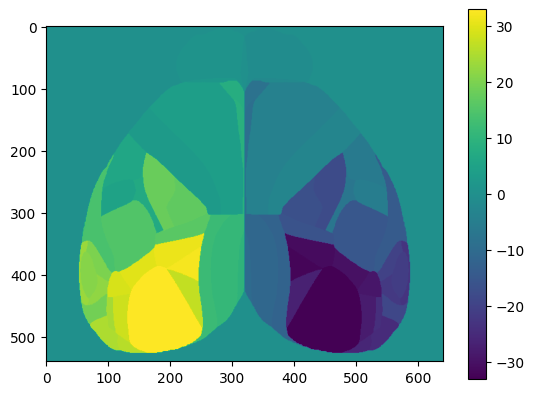

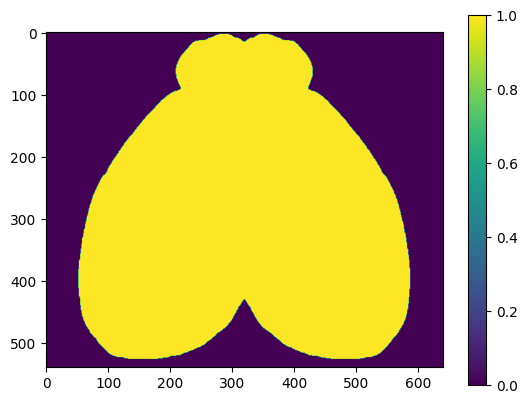

In [4]:
## brain mask and corresponding atlas is loaded at once
## Visualize
brainmask = np.load(pjoin(localdisk,'brain_mask.npy'))
atlas = np.load(pjoin(localdisk, "atlas.npy"))
plt.imshow(atlas); plt.colorbar(); plt.show()
plt.imshow(brainmask); plt.colorbar(); plt.show()

In [5]:
from wfield import *
lmarks = load_allen_landmarks(pjoin(localdisk,'analysis_landmarks.json'))
ccf_regions_reference,proj,brain_outline = allen_load_reference(reference_name='dorsal_cortex',
                                                                annotation_dir=pjoin(localdisk, "ccf"))
ccf_regions = allen_transform_regions(None,ccf_regions_reference,
                                      resolution = lmarks['resolution'],
                                        bregma_offset = lmarks['bregma_offset'])
print(ccf_regions.head())
ccf_index = ccf_regions["label"]
ccf_areaname = ccf_regions["acronym"]
print(ccf_index)
print(ccf_areaname)

  acronym                              name   reference  resolution  label  \
0     MOB               Main olfactory bulb  [540, 570]          10      1   
1     FRP     Frontal pole, cerebral cortex  [540, 570]          10      2   
2     MOp                Primary motor area  [540, 570]          10      3   
3     MOs              Secondary motor area  [540, 570]          10      4   
4   SSp-n  Primary somatosensory area, nose  [540, 570]          10      5   

   allen_id        allen_rgb                               left_center  \
0       507  [154, 210, 189]   [267.40032563917526, 49.87954874742269]   
1       184    [38, 143, 69]     [270.0095260257732, 88.3714727216495]   
2       985    [31, 157, 90]  [211.21544753608248, 215.04006754639175]   
3       993    [31, 157, 90]    [262.0959385618557, 175.2304084072165]   
4       353   [24, 128, 100]  [115.22286763402062, 273.35201564948454]   

                              right_center  \
0  [372.59967436082474, 637.508414726804

# Note that the data structure below is required

#### Say, the number of the atlas regions in this analysis is 50, 25 regions on either left/right side and 25 regions on the other side

  - **areainds** is python list of integer, which indicates single atlas region of CCF. [1,2,...25, -1,-2,...-25]<br>
  - **areanames** is python list of str, which is in the form of "acronym" + "_" + "R/L"<br>

  This python object is needs to be saved as **.mat** file format

  The implementation for creating and saving this python object is up to you

In [6]:
left_names = []
right_names = []
left_index = []
right_index = []
for index, name in enumerate(ccf_areaname, start=1):
  left_names.append(name+"_L")
  right_names.append(name+"_R")
  left_index.append(index)
  right_index.append(-index)

left_index.extend(right_index)
left_names.extend(right_names)

areainds = np.array(left_index)
areanames = np.array(left_names)
print(areainds)
print(areanames)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  -1  -2  -3
  -4  -5  -6  -7  -8  -9 -10 -11 -12 -13 -14 -15 -16 -17 -18 -19 -20 -21
 -22 -23 -24 -25 -26 -27 -28 -29 -30 -31 -32 -33]
['MOB_L' 'FRP_L' 'MOp_L' 'MOs_L' 'SSp-n_L' 'SSp-m_L' 'SSp-un_L' 'PL_L'
 'ACAd_L' 'RSPv_L' 'RSPd_L' 'RSPagl_L' 'VISC_L' 'SSs_L' 'SSp-bfd_L'
 'SSp-tr_L' 'SSp-ll_L' 'SSp-ul_L' 'TEa_L' 'AUDd_L' 'AUDp_L' 'AUDpo_L'
 'AUDv_L' 'VISli_L' 'VISpor_L' 'VISpl_L' 'VISpm_L' 'VISl_L' 'VISal_L'
 'VISrl_L' 'VISa_L' 'VISam_L' 'VISp_L' 'MOB_R' 'FRP_R' 'MOp_R' 'MOs_R'
 'SSp-n_R' 'SSp-m_R' 'SSp-un_R' 'PL_R' 'ACAd_R' 'RSPv_R' 'RSPd_R'
 'RSPagl_R' 'VISC_R' 'SSs_R' 'SSp-bfd_R' 'SSp-tr_R' 'SSp-ll_R' 'SSp-ul_R'
 'TEa_R' 'AUDd_R' 'AUDp_R' 'AUDpo_R' 'AUDv_R' 'VISli_R' 'VISpor_R'
 'VISpl_R' 'VISpm_R' 'VISl_R' 'VISal_R' 'VISrl_R' 'VISa_R' 'VISam_R'
 'VISp_R']


In [7]:
sio.savemat(pjoin(localdisk,"area_info.mat"), {"areainds":areainds, "areanames":areanames})

In [8]:
U = np.load(pjoin(localdisk,'U.npy'))
V = np.load(pjoin(localdisk,'SVTcorr.npy'))
# atlas = np.load(pjoin(localdisk, "atlas.npy")).astype('int8')
mask = np.load(pjoin(localdisk,'brain_mask.npy'))
lmarks = load_allen_landmarks(pjoin(localdisk, 'analysis_landmarks.json'))

In [9]:
Uatlas = U.copy()

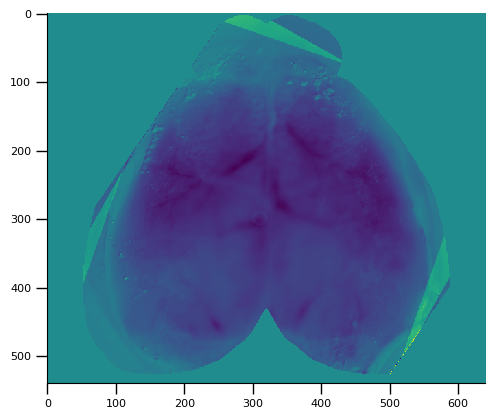

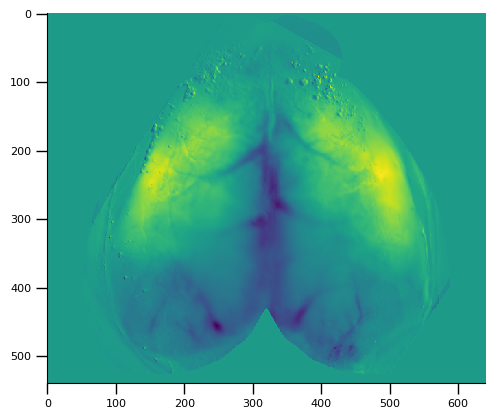

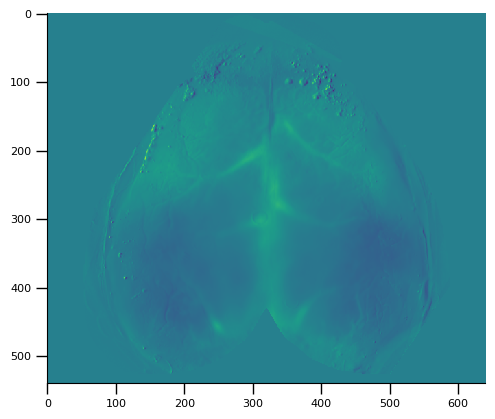

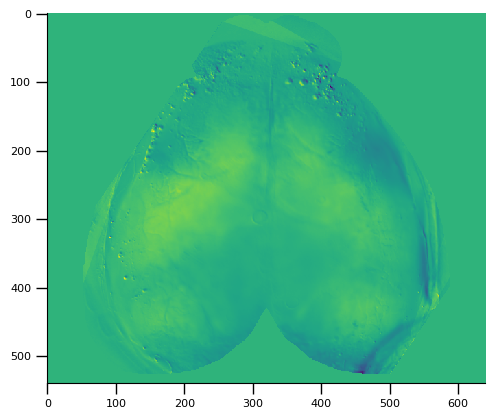

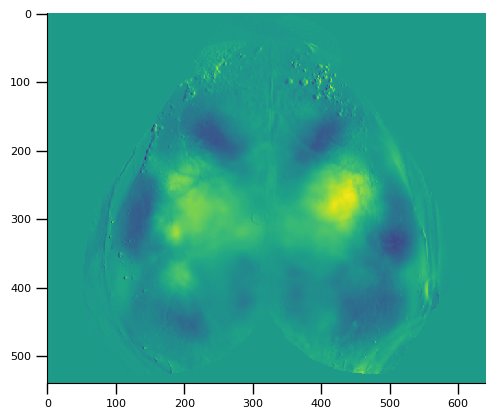

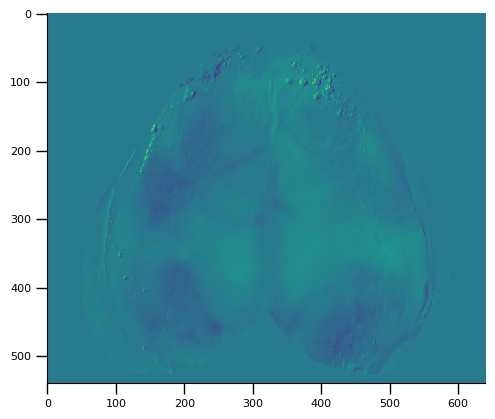

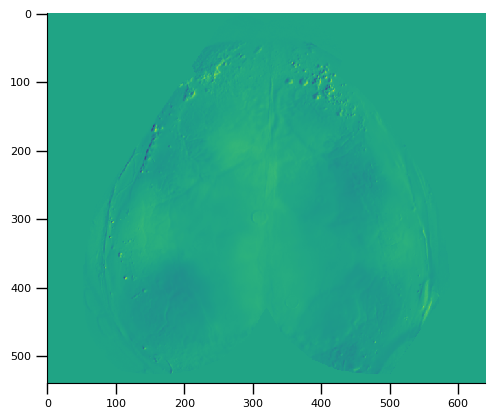

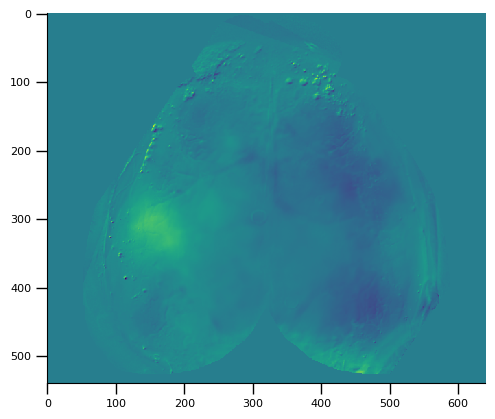

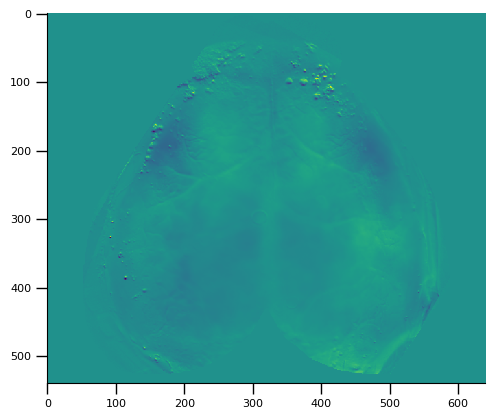

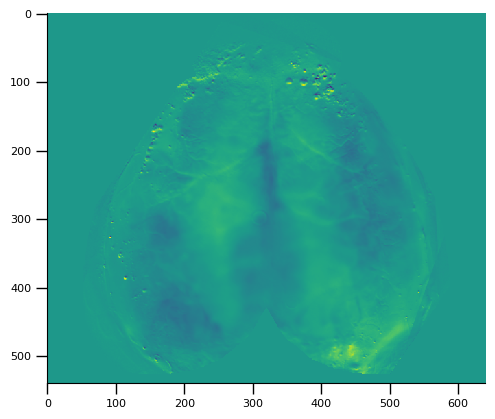

In [10]:
for i in range(10):
  plt.imshow(Uatlas[:,:,i]);plt.show()

In [11]:
# Perform the LQ decomposition. Time everything.
t0_global = time.time()
t0 = time.time()
if nonnegative_temporal:
    r = V.T
else:
    q, r = np.linalg.qr(V.T)
time_ests={'qr_decomp':time.time() - t0}

# Put in data structure for LocaNMF
video_mats = (np.copy(U[brainmask]), r.T)
del U

# region_mats[0] = [unique regions x pixels] the mask of each region
# region_mats[1] = [unique regions x pixels] the distance penalty of each region
# region_mats[2] = [unique regions] area code
region_mats = LocaNMF.extract_region_metadata(brainmask, atlas, min_size=min_pixels)

region_metadata = LocaNMF.RegionMetadata(region_mats[0].shape[0],
                                    region_mats[0].shape[1:],
                                    device=device)

region_metadata.set(torch.from_numpy(region_mats[0].astype(np.uint8)),
                    torch.from_numpy(region_mats[1]),
                    torch.from_numpy(region_mats[2].astype(np.int64)))

# Do SVD
if device=='cuda': torch.cuda.synchronize()
print('v SVD Initialization')
t0 = time.time()
region_videos = LocaNMF.factor_region_videos(video_mats,
                                            region_mats[0],
                                            rank_range[1],
                                            device=device)
if device=='cuda': torch.cuda.synchronize()
print("\'-total : %f" % (time.time() - t0))
time_ests['svd_init'] = time.time() - t0

low_rank_video = LocaNMF.LowRankVideo(
    (int(np.sum(brainmask)),) + video_mats[1].shape, device=device)
low_rank_video.set(torch.from_numpy(video_mats[0].T),
                torch.from_numpy(video_mats[1]))

if device=='cuda': torch.cuda.synchronize()
print('v Rank Line Search')
t0 = time.time()
locanmf_comps = LocaNMF.rank_linesearch(low_rank_video,
                                            region_metadata,
                                            region_videos,
                                            maxiter_rank=maxrank-minrank+1,
                                            maxiter_lambda=20,
                                            maxiter_hals=20,
                                            lambda_step=1.35,
                                            lambda_init=1e-6,
                                            loc_thresh=loc_thresh,
                                            r2_thresh=r2_thresh,
                                            rank_range=rank_range,
                                            nnt=nonnegative_temporal,
                                            verbose=[True, False, False],
                                            sample_prop=(1,1),
                                            device=device
                                        )
if device=='cuda': torch.cuda.synchronize()
print("\'-total : %f" % (time.time() - t0))
time_ests['rank_linesearch'] = time.time() - t0

# Evaluate R^2
_,r2_fit=LocaNMF.evaluate_fit_to_region(low_rank_video,
                                        locanmf_comps,
                                        region_metadata.support.data.sum(0),
                                        sample_prop=(1, 1))
print("R^2 fit on all data : %f" % r2_fit)

time_ests['global_time'] = time.time()-t0_global

# Assigning regions to components
region_ranks = []; region_idx = []

for rdx in torch.unique(locanmf_comps.regions.data, sorted=True):
    region_ranks.append(torch.sum(rdx == locanmf_comps.regions.data).item())
    region_idx.append(rdx.item())

areas=region_metadata.labels.data[locanmf_comps.regions.data].cpu().numpy()

# Get LocaNMF spatial and temporal components
A=locanmf_comps.spatial.data.cpu().numpy().T
A_reshape=np.zeros((brainmask.shape[0],brainmask.shape[1],A.shape[1])); A_reshape.fill(np.nan)
A_reshape[brainmask,:]=A

if nonnegative_temporal:
    C=locanmf_comps.temporal.data.cpu().numpy()
else:
    C=np.matmul(q,locanmf_comps.temporal.data.cpu().numpy().T).T

sortvec=np.argsort(areas)
C=C[sortvec,:]
A_reshape=A_reshape[:,:,sortvec]
lambdas=np.squeeze(locanmf_comps.lambdas.data.cpu().numpy())
lambdas=lambdas[sortvec]
areas=areas[sortvec]
areainds,areanames_all = parse_areanames(pjoin(localdisk,"area_info.mat"))
areanames_area=[]
for i,area in enumerate(areas):
    areanames_area.append(areanames_all[areainds.index(area)])

sio.savemat(pjoin(localdisk, 'locanmf_decomp_loc'+str(loc_thresh)+'.mat'),
    {'C':C,
      'A':A_reshape,
      'lambdas':locanmf_comps.lambdas.data.cpu().numpy(),
      'areas':areas,
      'r2_fit':r2_fit,
      'time_ests':time_ests,
      'areanames':areanames_area
    })

torch.cuda.empty_cache()
# plot_components(A_reshape,C,areas,atlas,pjoin(localdisk,"area_info.mat") , day_path)
# plot_correlations(A_reshape,C,areas,atlas, pjoin(localdisk,"area_info.mat")  , day_path)

v SVD Initialization
'-total : 1.149819
v Rank Line Search
|--v Rank Line Search Iteration 0
|  |--v Initialization
|  |  '-total : 0.088821 seconds
|  |--v Lambda Line Search
|  |  '- 20 iterations took 7.95403 seconds
|  |--> R2 Evaluation took 0.129736 seconds
|  '-total : 8.17294 seconds
|--v Rank Line Search Iteration 1
|  |--v Initialization
|  |  '-total : 1.062389 seconds
|  |--v Lambda Line Search
|  |  '- 20 iterations took 23.9211 seconds
|  |--> R2 Evaluation took 0.0220807 seconds
|  '-total : 25.0068 seconds
|--v Rank Line Search Iteration 2
|  |--v Initialization
|  |  '-total : 0.844843 seconds
|  |--v Lambda Line Search
|  |  '- 20 iterations took 27.1759 seconds
|  |--> R2 Evaluation took 0.00986958 seconds
|  '-total : 28.032 seconds
'-total : 62.507149
R^2 fit on all data : 0.992432


In [12]:
plot_components(A_reshape,C,areas,atlas,pjoin(localdisk,"area_info.mat") , localdisk)
plot_correlations(A_reshape,C,areas,atlas, pjoin(localdisk,"area_info.mat")  , localdisk)

plotting components


plotting correlations


'/content/drive/MyDrive/workdir/wfci/analysis/Figures'